<a href="https://colab.research.google.com/github/ericphann/video-game-super-resolution/blob/main/base_models/GAN_base_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Super-Resolution GAN for Video Game Image Enhancement

### Cost/Loss Functions
The model employs a sophisticated combination of loss functions inspired by the ESRGAN architecture:

- Perceptual Loss: This leverages a pre-trained VGG19 network to extract feature representations from multiple layers. By minimizing the L1 distance between the features of the ground truth and generated images, the model preserves perceptual information beyond simple pixel values.

- Pixel-wise Loss: A direct L1 loss between the generated super-resolution image and the high-resolution ground truth ensures structural similarity at the pixel level.

- Adversarial Loss: Binary cross-entropy adversarial loss from the discriminator helps the generator produce images that appear realistic rather than just minimizing pixel differences.

These loss components are combined with specific weights (0.01 for pixel loss, 1.0 for perceptual loss, 0.005 for adversarial loss) to form the complete generator loss function. This multi-term approach balances low-level pixel accuracy with high-level perceptual quality.

In [1]:
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import os
import numpy as np
import tensorflow as tf
import random
from glob import glob
import tqdm as notebook_tqdm
from PIL import Image


# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

### Downloading the Data

In [2]:
from huggingface_hub import HfApi, hf_hub_download
import time
import shutil

# Initialize HF API
api = HfApi()

# Dataset repository
repo_id = "ericphann/video-game-super-resolution"

# Define folders
folders = [
    "test-hr", "test-lr",
    "training-hr", "training-lr",
    "validation-hr", "validation-lr"
]

# Create local directory
local_dir = "super_res_subset"
os.makedirs(local_dir, exist_ok=True)

# Download first 50 images from each folder
for folder in folders:
    # Create folder
    folder_path = os.path.join(local_dir, folder)
    os.makedirs(folder_path, exist_ok=True)

    # Get list of files in the folder
    all_files = api.list_repo_files(repo_id, repo_type="dataset")
    folder_files = [f for f in all_files if f.startswith(folder + "/")]

    # Sort files and take first 50
    files_sorted = sorted(folder_files)[:50]

    # Download each file with a delay
    for file in files_sorted:
        # Extract just the filename
        filename = os.path.basename(file)

        # Use a temporary directory for downloads
        temp_dir = os.path.join(local_dir, "temp")
        os.makedirs(temp_dir, exist_ok=True)

        # Download the file
        downloaded_file = hf_hub_download(
            repo_id=repo_id,
            filename=file,
            repo_type="dataset",
            local_dir=temp_dir
        )

        # Move file to its final destination
        dest_path = os.path.join(folder_path, filename)
        shutil.copy2(downloaded_file, dest_path)

        # Wait to avoid rate limiting
        time.sleep(1)

    print(f"Downloaded {len(files_sorted)} images from {folder}")

# Clean up temporary directory
shutil.rmtree(os.path.join(local_dir, "temp"), ignore_errors=True)

12266.png:   0%|          | 0.00/3.33M [00:00<?, ?B/s]

12267.png:   0%|          | 0.00/4.19M [00:00<?, ?B/s]

12268.png:   0%|          | 0.00/3.24M [00:00<?, ?B/s]

12269.png:   0%|          | 0.00/2.82M [00:00<?, ?B/s]

12270.png:   0%|          | 0.00/2.56M [00:00<?, ?B/s]

...

10046.png:   0%|          | 0.00/196k [00:00<?, ?B/s]

10047.png:   0%|          | 0.00/183k [00:00<?, ?B/s]

10048.png:   0%|          | 0.00/244k [00:00<?, ?B/s]

10049.png:   0%|          | 0.00/250k [00:00<?, ?B/s]

Downloaded 50 images from validation-lr


### Creating the Datasets

In [16]:
# Create datasets for training, validation, and testing
def ensure_dir(directory):
    """Create directory if it doesn't exist"""
    if not os.path.exists(directory):
        os.makedirs(directory)
        print(f"Created directory: {directory}")

def create_dataset(lr_dir, hr_dir, batch_size=4, shuffle=True, buffer_size=1000):
    """
    Create a TensorFlow dataset for super-resolution GAN training.
    Handles 270p to 1080p image pairs.
    """
    # Get sorted lists of file paths
    lr_files = sorted([os.path.join(lr_dir, f) for f in os.listdir(lr_dir)
                      if f.endswith('.png') or f.endswith('.jpg')])
    hr_files = sorted([os.path.join(hr_dir, f) for f in os.listdir(hr_dir)
                      if f.endswith('.png') or f.endswith('.jpg')])

    # Ensure we have matching pairs
    print(f"Found {len(lr_files)} LR images and {len(hr_files)} HR images")

    # Create TensorFlow datasets from file paths - convert to string type explicitly
    lr_ds = tf.data.Dataset.from_tensor_slices(tf.constant(lr_files))
    hr_ds = tf.data.Dataset.from_tensor_slices(tf.constant(hr_files))

    # Define preprocessing functions
    def preprocess_lr(image_path):
        img = tf.io.read_file(image_path)
        img = tf.image.decode_png(img, channels=3)

        # Scale to [-1, 1] for GAN training
        img = tf.image.convert_image_dtype(img, tf.float32)
        img = (img * 2) - 1
        return img

    def preprocess_hr(image_path):
        img = tf.io.read_file(image_path)
        img = tf.image.decode_png(img, channels=3)

        # Scale to [-1, 1] for GAN training
        img = tf.image.convert_image_dtype(img, tf.float32)
        img = (img * 2) - 1
        return img

    # Load and preprocess the images
    lr_ds = lr_ds.map(preprocess_lr, num_parallel_calls=tf.data.AUTOTUNE)
    hr_ds = hr_ds.map(preprocess_hr, num_parallel_calls=tf.data.AUTOTUNE)

    # Zip the datasets together
    dataset = tf.data.Dataset.zip((lr_ds, hr_ds))

    # Shuffle with a good buffer size for GANs
    if shuffle:
        dataset = dataset.shuffle(buffer_size=buffer_size)

    # Use smaller batch sizes for GAN training
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

# Print some diagnostics
print(f"Data directory: {local_dir}")
print(f"Training LR directory exists: {os.path.exists(os.path.join(local_dir, 'training-lr'))}")
print(f"Training HR directory exists: {os.path.exists(os.path.join(local_dir, 'training-hr'))}")

# Create the datasets
train_ds = create_dataset(
    os.path.join(local_dir, "training-lr"),
    os.path.join(local_dir, "training-hr"),
    batch_size=4,
    shuffle=True
)

val_ds = create_dataset(
    os.path.join(local_dir, "validation-lr"),
    os.path.join(local_dir, "validation-hr"),
    batch_size=4,
    shuffle=False
)

test_ds = create_dataset(
    os.path.join(local_dir, "test-lr"),
    os.path.join(local_dir, "test-hr"),
    batch_size=4,
    shuffle=False
)

Data directory: super_res_subset
Training LR directory exists: True
Training HR directory exists: True
Found 50 LR images and 50 HR images
Found 50 LR images and 50 HR images
Found 50 LR images and 50 HR images


In [17]:
# load sample images
low_res = Image.open('super_res_subset/training-lr/00000.png')
high_res = Image.open('super_res_subset/training-hr/00000.png')

# print dimensions
print(f'Low-res image dimensions: {low_res.size}')
print(f'High-res image dimensions: {high_res.size}')

Low-res image dimensions: (480, 270)
High-res image dimensions: (1920, 1080)


### Visualizing Sample Data

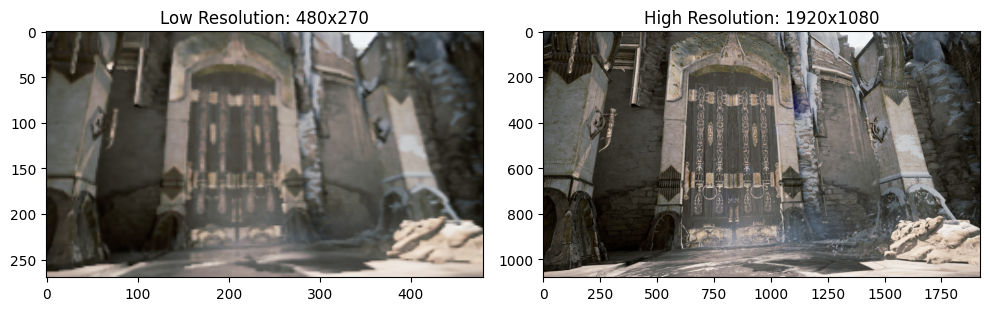

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(np.array(low_res))
plt.title(f'Low Resolution: {low_res.size[0]}x{low_res.size[1]}')

plt.subplot(1,2,2)
plt.imshow(np.array(high_res))
plt.title(f'High Resolution: {high_res.size[0]}x{high_res.size[1]}')

plt.tight_layout()
plt.show()

In [19]:
print("TF version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# Define dataset paths
data_dir = "super_res_subset"
paths = {
    "train_hr": sorted(glob(f"{data_dir}/training-hr/*")),
    "train_lr": sorted(glob(f"{data_dir}/training-lr/*")),
    "val_hr": sorted(glob(f"{data_dir}/validation-hr/*")),
    "val_lr": sorted(glob(f"{data_dir}/validation-lr/*")),
    "test_hr": sorted(glob(f"{data_dir}/test-hr/*")),
    "test_lr": sorted(glob(f"{data_dir}/test-lr/*"))
}

print(f"Training samples: {len(paths['train_hr'])}")
print(f"Validation samples: {len(paths['val_hr'])}")
print(f"Test samples: {len(paths['test_hr'])}")

TF version: 2.18.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Training samples: 50
Validation samples: 50
Test samples: 50


### Hyperparameters

- Learning Rates: Discriminator (5e-5), Generator (1e-3) - differential rates help balance training
- Batch Size: 4 images per batch
- Training Duration: 100 epochs
- Residual Blocks: 16 RRDB blocks in generator
- Generator Updates per Discriminator Update: 2 (helps generator keep pace)
- Label Smoothing: Real labels set to 0.9 instead of 1.0
- LeakyReLU Alpha: 0.2 for all leaky ReLU activations
- Optimizer: Adam with beta1=0.9, beta2=0.99

In [20]:
# Default values with updated hyperparameters
LEARNING_RATE_DISCRIMINATOR = 5e-5  # Reduced discriminator learning rate
LEARNING_RATE_GENERATOR = 1e-3      # Increased generator learning rate
BATCH_SIZE = 4
EPOCHS = 100
NUM_RESIDUAL_BLOCKS = 16
LEAKYRELU_ALPHA = 0.2
GENERATOR_UPDATES_PER_DISCRIMINATOR = 2

# Patch sizes for processing
LR_PATCH_SIZE = 64  # Low-resolution patch size
HR_PATCH_SIZE = 256  # High-resolution patch size (4x upsampled)
SCALE_FACTOR = 4

# Data directory
data_dir = "super_res_subset"

### Modeling Architecture
#### Generator

- Base Architecture: Enhanced residual network with 16 Residual-in-Residual Dense Blocks (RRDB)
- Input: 64×64×3 low-resolution images
- Output: 256×256×3 super-resolution images (4× upscaling)
- Dense Connections: Implemented within residual blocks to enhance information flow
- Upsampling: Two transposed convolution layers with stride 2 for 4× scaling

In [21]:
# Create the generator model (works on patches)

# Enhanced generator with more capacity
def build_generator(leakyrelu_alpha=0.2, num_residual_blocks=16, filters=64):
    # Input is low-resolution patch
    inputs = layers.Input(shape=(LR_PATCH_SIZE, LR_PATCH_SIZE, 3))

    # Initial convolutional layer with more filters
    x = layers.Conv2D(filters, kernel_size=9, padding='same')(inputs)
    x = layers.LeakyReLU(negative_slope=leakyrelu_alpha)(x)

    # Store the output of the first convolution for the residual connection
    skip_connection = x

    # RRDB (Residual in Residual Dense Block) structure similar to ESRGAN
    def residual_dense_block(x, filters=32):
        # Dense connections
        x1 = layers.Conv2D(filters, kernel_size=3, padding='same')(x)
        x1 = layers.LeakyReLU(negative_slope=leakyrelu_alpha)(x1)

        x2 = layers.Concatenate()([x, x1])
        x2 = layers.Conv2D(filters, kernel_size=3, padding='same')(x2)
        x2 = layers.LeakyReLU(negative_slope=leakyrelu_alpha)(x2)

        x3 = layers.Concatenate()([x, x1, x2])
        x3 = layers.Conv2D(filters, kernel_size=3, padding='same')(x3)
        x3 = layers.LeakyReLU(negative_slope=leakyrelu_alpha)(x3)

        x4 = layers.Concatenate()([x, x1, x2, x3])
        x4 = layers.Conv2D(filters, kernel_size=3, padding='same')(x4)
        x4 = layers.LeakyReLU(negative_slope=leakyrelu_alpha)(x4)

        x5 = layers.Concatenate()([x, x1, x2, x3, x4])
        x5 = layers.Conv2D(filters * 2, kernel_size=3, padding='same')(x5)

        # Scale factor for stability
        return x + x5 * 0.2

    # RRDB blocks
    for _ in range(num_residual_blocks):
        x = residual_dense_block(x, filters//2)

    # Post-residual convolutional layer
    x = layers.Conv2D(filters, kernel_size=3, padding='same')(x)
    x = layers.BatchNormalization()(x)

    # Add the skip connection
    x = layers.Add()([x, skip_connection])

    # Upsampling blocks (4x upsampling)
    for _ in range(2):  # Two upsampling blocks for 4x upscaling
        x = layers.Conv2DTranspose(filters * 2, kernel_size=3, strides=2, padding='same')(x)
        x = layers.LeakyReLU(negative_slope=leakyrelu_alpha)(x)

    # Final convolutional layer with more filters
    x = layers.Conv2D(filters, kernel_size=3, padding='same')(x)
    x = layers.LeakyReLU(negative_slope=leakyrelu_alpha)(x)

    # Output layer
    outputs = layers.Conv2D(3, kernel_size=9, padding='same', activation='tanh')(x)

    model = models.Model(inputs, outputs)
    return model

#### Discriminator

- Structure: Convolutional neural network with leaky ReLU activations
- Input: 256×256×3 images (both real high-resolution and generated)
- Feature Extraction: Multiple convolutional layers with increasing filters (64→256)
- Classification: Global average pooling followed by dense layers
- Regularization: Gaussian noise input layer (stddev=0.05) and dropout (0.2-0.3)

In [22]:
# Create the discriminator model (works on patches) with added noise and dropout
def build_discriminator(leakyrelu_alpha=0.2):
    # Input is high-resolution patch
    inputs = layers.Input(shape=(HR_PATCH_SIZE, HR_PATCH_SIZE, 3))

    # Add Gaussian noise to inputs to prevent discriminator from becoming too confident
    x = layers.GaussianNoise(0.05)(inputs)  # Added noise layer

    # First convolutional block without batch normalization
    x = layers.Conv2D(64, kernel_size=3, strides=1, padding='same')(x)
    x = layers.LeakyReLU(negative_slope=leakyrelu_alpha)(x)

    # Downsampling convolutional blocks with increasing filters
    filter_sizes = [64, 128, 128, 256, 256]
    strides = [2, 1, 2, 1, 2]  # Alternating strides

    for filters, stride in zip(filter_sizes, strides):
        x = layers.Conv2D(filters, kernel_size=3, strides=stride, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.LeakyReLU(negative_slope=leakyrelu_alpha)(x)
        x = layers.Dropout(0.2)(x)  # Added dropout for regularization

    # Global average pooling instead of flatten to reduce parameters
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512)(x)
    x = layers.LeakyReLU(negative_slope=leakyrelu_alpha)(x)
    x = layers.Dropout(0.3)(x)  # Added dropout

    # Output layer with sigmoid activation
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)
    return model

### Adversarial Model Architecture
The adversarial model represents the combined generator-discriminator architecture in our GAN framework:

- Structure: The adversarial model connects the generator's output directly to the discriminator, creating an end-to-end pipeline.

- Input → Output Path: Low-resolution image (64×64×3) → Generator → Super-resolution image (256×256×3) → Discriminator → Realness score (0-1)

- Weight Freezing: During adversarial training, the discriminator's weights are frozen (non-trainable) within this combined model, ensuring that only the generator parameters are updated.

- Implementation: Created using a Keras functional API approach with a clone of the discriminator to maintain weight separation between standalone discriminator training and adversarial training.

- Training Methodology: A custom training loop implements a minimax game where the generator attempts to maximize the discriminator's error by producing increasingly realistic images.

In [23]:
# Create adversarial model (Generator + Discriminator)
def build_adversarial_model(generator, discriminator):
    # Clone the discriminator to ensure trainability separation
    for layer in discriminator.layers:
        layer.trainable = True  # Ensure the original discriminator remains trainable

    # For the adversarial model, we don't train discriminator weights
    discriminator_clone = tf.keras.models.clone_model(discriminator)
    discriminator_clone.set_weights(discriminator.get_weights())
    discriminator_clone.trainable = False

    # GAN input is low-resolution patch
    gan_input = layers.Input(shape=(LR_PATCH_SIZE, LR_PATCH_SIZE, 3))

    # Generate high-resolution patch
    gen_output = generator(gan_input)

    # Discriminator evaluates generator output
    gan_output = discriminator_clone(gen_output)

    # Combined model (only generator weights are trainable)
    model = models.Model(gan_input, gan_output)
    return model

# Function to build and compile models with given hyperparameters
def build_and_compile_models(lr_discriminator, lr_generator, leakyrelu_alpha, num_residual_blocks):
    # Create models with tuned hyperparameters
    generator = build_generator(leakyrelu_alpha=leakyrelu_alpha,
                              num_residual_blocks=num_residual_blocks)

    discriminator = build_discriminator(leakyrelu_alpha=leakyrelu_alpha)

    adversarial_model = build_adversarial_model(generator, discriminator)

    # Compile models with different learning rates
    discriminator.compile(
        loss='binary_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr_discriminator),
        metrics=['accuracy']
    )

    adversarial_model.compile(
        loss='binary_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr_generator)
    )

    return generator, discriminator, adversarial_model

### VGG Feature Extractor
The VGG feature extractor serves as the backbone of the perceptual loss function:

- Base Model: Pre-trained VGG19 network trained on ImageNet, with top classification layers removed.
- Layer Selection: Features are extracted from five strategically selected layers: 'block1_conv2', 'block2_conv2', 'block3_conv4', 'block4_conv4', and 'block5_conv4'. These layers capture information at different abstraction levels:

- Early layers: Textures, edges, colors
- Middle layers: Patterns and parts
- Deeper layers: Higher-level semantic content

- Preprocessing: Input images are converted from [-1,1] range to [0,255] and then preprocessed according to VGG19 requirements.
- Non-trainable: The VGG network is kept completely frozen (weights are non-trainable) as it serves purely as a feature extractor.
- Feature Comparison: L1 distance between features extracted from real and generated images forms the perceptual loss component, which guides the generator to produce images with similar feature representations to real high-resolution images.

In [24]:
# Perceptual Loss function using VGG19
def build_vgg19_feature_extractor():
    """
    Build a VGG19 feature extractor for perceptual loss.
    """
    # Load pre-trained VGG19 model
    vgg = tf.keras.applications.VGG19(include_top=False, weights='imagenet')

    # Set it to non-trainable
    vgg.trainable = False

    # Create feature extractor model (using conv4_4 output)
    # We'll extract features from multiple layers
    outputs = [vgg.get_layer(name).output for name in
              ['block1_conv2', 'block2_conv2', 'block3_conv4', 'block4_conv4', 'block5_conv4']]

    model = tf.keras.Model([vgg.input], outputs)
    return model

# Custom loss functions
class PerceptualLoss(tf.keras.losses.Loss):
    def __init__(self, feature_extractor):
        super(PerceptualLoss, self).__init__()
        self.feature_extractor = feature_extractor

    def call(self, hr_true, sr_pred):
        # VGG works with RGB images in [0, 255] and specific preprocessing
        def _preprocess(x):
            x = (x + 1) * 127.5  # Convert from [-1, 1] to [0, 255]
            return tf.keras.applications.vgg19.preprocess_input(x)

        hr_true_processed = _preprocess(hr_true)
        sr_pred_processed = _preprocess(sr_pred)

        # Ensure inputs match expected shape
        if hr_true_processed.shape.ndims == 3:
            hr_true_processed = tf.expand_dims(hr_true_processed, 0)
        if sr_pred_processed.shape.ndims == 3:
            sr_pred_processed = tf.expand_dims(sr_pred_processed, 0)

        hr_features = self.feature_extractor(hr_true_processed)
        sr_features = self.feature_extractor(sr_pred_processed)

        # Calculate content loss (L1 loss between features)
        content_loss = 0
        for hr_feat, sr_feat in zip(hr_features, sr_features):
            content_loss += tf.reduce_mean(tf.abs(hr_feat - sr_feat))

        return content_loss

# Combined loss for the generator
class ESRGANGeneratorLoss(tf.keras.losses.Loss):
    def __init__(self, feature_extractor, adv_weight=0.005, content_weight=1.0, pixel_weight=0.01):
        super(ESRGANGeneratorLoss, self).__init__()
        self.feature_extractor = feature_extractor
        self.perceptual_loss = PerceptualLoss(feature_extractor)
        self.bce_loss = tf.keras.losses.BinaryCrossentropy()
        self.adv_weight = adv_weight
        self.content_weight = content_weight
        self.pixel_weight = pixel_weight

    def call(self, hr_true, sr_pred, disc_pred_real=None):
        # Pixel loss (L1)
        pixel_loss = tf.reduce_mean(tf.abs(hr_true - sr_pred))

        # Perceptual loss
        content_loss = self.perceptual_loss(hr_true, sr_pred)

        # Total loss
        return (self.pixel_weight * pixel_loss +
                self.content_weight * content_loss)

# Class to train the model with the custom losses
class ESRGANTrainer:
    def __init__(self, generator, discriminator, feature_extractor,
                 lr_generator=1e-4, lr_discriminator=1e-5,
                 adv_weight=0.005, content_weight=1.0, pixel_weight=0.01):

        self.generator = generator
        self.discriminator = discriminator
        self.feature_extractor = feature_extractor

        # Loss functions
        self.perceptual_loss = PerceptualLoss(feature_extractor)
        self.gan_loss = ESRGANGeneratorLoss(
            feature_extractor,
            adv_weight=adv_weight,
            content_weight=content_weight,
            pixel_weight=pixel_weight
        )
        self.bce_loss = tf.keras.losses.BinaryCrossentropy()

        # Optimizers
        self.gen_optimizer = tf.keras.optimizers.Adam(learning_rate=lr_generator, beta_1=0.9, beta_2=0.99)
        self.disc_optimizer = tf.keras.optimizers.Adam(learning_rate=lr_discriminator, beta_1=0.9, beta_2=0.99)

        # Weights
        self.adv_weight = adv_weight
        self.content_weight = content_weight
        self.pixel_weight = pixel_weight

    @tf.function
    def train_step(self, lr_batch, hr_batch):
        # Add noise to images (helps with stability)
        noise_stddev = 0.05
        hr_noisy = hr_batch + tf.random.normal(shape=tf.shape(hr_batch), mean=0, stddev=noise_stddev)

        # Train discriminator
        with tf.GradientTape() as disc_tape:
            # Generate images
            sr_batch = self.generator(lr_batch, training=True)
            sr_noisy = sr_batch + tf.random.normal(shape=tf.shape(sr_batch), mean=0, stddev=noise_stddev)

            # Get discriminator predictions
            hr_prob = self.discriminator(hr_noisy, training=True)
            sr_prob = self.discriminator(sr_noisy, training=True)

            # Label smoothing
            real_labels = tf.ones_like(hr_prob) * 0.9
            fake_labels = tf.zeros_like(sr_prob)

            # Discriminator losses
            real_loss = self.bce_loss(real_labels, hr_prob)
            fake_loss = self.bce_loss(fake_labels, sr_prob)
            disc_loss = real_loss + fake_loss

        # Apply discriminator gradients
        disc_grads = disc_tape.gradient(disc_loss, self.discriminator.trainable_variables)
        self.disc_optimizer.apply_gradients(zip(disc_grads, self.discriminator.trainable_variables))

        # Train generator (multiple times)
        gen_loss = 0
        for _ in range(GENERATOR_UPDATES_PER_DISCRIMINATOR):
            with tf.GradientTape() as gen_tape:
                # Generate images
                sr_batch = self.generator(lr_batch, training=True)

                # Get discriminator predictions on generated images
                sr_prob = self.discriminator(sr_batch, training=False)

                # Adversarial loss (fool the discriminator)
                adv_loss = self.bce_loss(tf.ones_like(sr_prob), sr_prob)

                # Perceptual loss
                content_loss = self.perceptual_loss(hr_batch, sr_batch)

                # Pixel loss
                pixel_loss = tf.reduce_mean(tf.abs(hr_batch - sr_batch))

                # Combined loss
                total_gen_loss = (self.adv_weight * adv_loss +
                                 self.content_weight * content_loss +
                                 self.pixel_weight * pixel_loss)
                gen_loss = total_gen_loss

            # Apply generator gradients
            gen_grads = gen_tape.gradient(total_gen_loss, self.generator.trainable_variables)
            self.gen_optimizer.apply_gradients(zip(gen_grads, self.generator.trainable_variables))

        return {
            'disc_loss': disc_loss,
            'gen_loss': gen_loss,
            'adv_loss': adv_loss,
            'content_loss': content_loss,
            'pixel_loss': pixel_loss
        }

    def train(self, train_ds, val_ds, epochs=100):
        # History dictionary to track losses
        history = {
            'disc_loss': [],
            'gen_loss': [],
            'val_psnr': []
        }

        for epoch in range(epochs):
            print(f"Epoch {epoch+1}/{epochs}")

            # Training metrics
            disc_losses = []
            gen_losses = []

            # Train on batches
            for batch_idx, (lr_batch, hr_batch) in enumerate(train_ds):
                # Train on batch
                losses = self.train_step(lr_batch, hr_batch)

                # Record losses
                disc_losses.append(float(losses['disc_loss']))
                gen_losses.append(float(losses['gen_loss']))

                # Print progress
                if batch_idx % 10 == 0:
                    print(f"Batch {batch_idx}: D loss: {losses['disc_loss']:.4f}, G loss: {losses['gen_loss']:.4f}")

            # Compute epoch average losses
            avg_disc_loss = np.mean(disc_losses)
            avg_gen_loss = np.mean(gen_losses)

            # Record history
            history['disc_loss'].append(avg_disc_loss)
            history['gen_loss'].append(avg_gen_loss)

            print(f"Epoch {epoch+1} - D loss: {avg_disc_loss:.4f}, G loss: {avg_gen_loss:.4f}")

            # Validate and save sample images
            if (epoch + 1) % 5 == 0 or epoch == 0:
                # Generate a sample image
                for lr_batch, hr_batch in val_ds.take(1):
                    # Generate SR image
                    sr_batch = self.generator(lr_batch)

                    # Choose one image from the batch
                    lr_img = lr_batch[0]
                    hr_img = hr_batch[0]
                    sr_img = sr_batch[0]

                    # Convert to [0, 1] for display
                    lr_img = (lr_img + 1) / 2
                    hr_img = (hr_img + 1) / 2
                    sr_img = (sr_img + 1) / 2

                    # Plot images
                    plt.figure(figsize=(15, 5))
                    plt.subplot(1, 3, 1)
                    plt.title('Low Resolution')
                    plt.imshow(lr_img)

                    plt.subplot(1, 3, 2)
                    plt.title('Super Resolution')
                    plt.imshow(sr_img)

                    plt.subplot(1, 3, 3)
                    plt.title('High Resolution')
                    plt.imshow(hr_img)

                    plt.savefig(f'epoch_{epoch+1}_sample.png')
                    plt.close()

                # Save model
                self.generator.save(f'generator_epoch_{epoch+1}.keras')

        return history

### Patch Dataset Creation and Processing
The patch-based approach is a critical component of our super-resolution pipeline, enabling efficient and effective training while managing memory constraints:

**Dataset Structure**

- Source: The dataset consists of video game screenshots from the our repository on Hugging Face
- Organization: Split into training, validation, and test sets with paired low-resolution (270p) and high-resolution (1080p) images
- Scale Factor: 4× upscaling (270p → 1080p) maintained throughout the dataset

**Patch Extraction Strategy**

- Patch Dimensions:

 - Low-Resolution: 64×64×3 pixels
 - High-Resolution: 256×256×3 pixels (4× scale)

- Extraction Method: Direct resizing of images to target patch sizes rather than random cropping, chosen for training stability
- Preprocessing:

 - Images converted to floating-point format [0,1]
 - Normalized to [-1,1] range for GAN training
 - Robust error handling implemented to manage inconsistent image dimensions

In [25]:
# Create direct patches from images with simplified, robust approach
def create_direct_patches(lr_dir, hr_dir, lr_size=64, hr_size=256, batch_size=4, shuffle=True):
    """
    Create patches directly from image files, using a simplified and robust approach.
    """
    # Get sorted lists of file paths
    lr_files = sorted([os.path.join(lr_dir, f) for f in os.listdir(lr_dir)
                     if f.endswith('.png') or f.endswith('.jpg')])
    hr_files = sorted([os.path.join(hr_dir, f) for f in os.listdir(hr_dir)
                     if f.endswith('.png') or f.endswith('.jpg')])

    print(f"Found {len(lr_files)} LR files and {len(hr_files)} HR files")

    # Function to load and process a single image pair
    def load_and_patch(lr_path, hr_path):
        """
        Load image pairs and create patches with robust error handling.
        """
        try:
            # Read LR image
            lr_img = tf.io.read_file(lr_path)
            lr_img = tf.image.decode_png(lr_img, channels=3)
            lr_img = tf.image.convert_image_dtype(lr_img, tf.float32)

            # Read HR image
            hr_img = tf.io.read_file(hr_path)
            hr_img = tf.image.decode_png(hr_img, channels=3)
            hr_img = tf.image.convert_image_dtype(hr_img, tf.float32)

            # Simplest approach: resize images directly to target patch size
            # This avoids all crop-related errors
            lr_patch = tf.image.resize(lr_img, [lr_size, lr_size])
            hr_patch = tf.image.resize(hr_img, [hr_size, hr_size])

            # Scale to [-1, 1] for GAN training
            lr_patch = (lr_patch * 2) - 1
            hr_patch = (hr_patch * 2) - 1

            return lr_patch, hr_patch

        except Exception as e:
            # Return blank patches if there's any error
            print(f"Error processing images: {e}")
            lr_patch = tf.zeros([lr_size, lr_size, 3], dtype=tf.float32)
            hr_patch = tf.zeros([hr_size, hr_size, 3], dtype=tf.float32)
            return lr_patch, hr_patch

    # Create dataset from file paths
    dataset = tf.data.Dataset.from_tensor_slices((lr_files, hr_files))

    # Shuffle if needed
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(lr_files))

    # Map load and patch function
    dataset = dataset.map(
        lambda lr_path, hr_path: tf.py_function(
            func=load_and_patch,
            inp=[lr_path, hr_path],
            Tout=[tf.float32, tf.float32]
        ),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # Set shapes explicitly to avoid shape issues
    dataset = dataset.map(
        lambda lr, hr: (
            tf.ensure_shape(lr, [lr_size, lr_size, 3]),
            tf.ensure_shape(hr, [hr_size, hr_size, 3])
        )
    )

    # Batch and prefetch
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

In [26]:
# Create datasets with direct patch extraction
def create_patch_datasets(data_dir, batch_size=4):
    # Define paths
    train_lr_path = os.path.join(data_dir, "training-lr")
    train_hr_path = os.path.join(data_dir, "training-hr")
    val_lr_path = os.path.join(data_dir, "validation-lr")
    val_hr_path = os.path.join(data_dir, "validation-hr")
    test_lr_path = os.path.join(data_dir, "test-lr")
    test_hr_path = os.path.join(data_dir, "test-hr")

    # Create patch-based datasets directly
    print("Creating training patches...")
    train_patches = create_direct_patches(train_lr_path, train_hr_path,
                                         lr_size=LR_PATCH_SIZE, hr_size=HR_PATCH_SIZE,
                                         batch_size=batch_size, shuffle=True)

    print("Creating validation patches...")
    val_patches = create_direct_patches(val_lr_path, val_hr_path,
                                       lr_size=LR_PATCH_SIZE, hr_size=HR_PATCH_SIZE,
                                       batch_size=batch_size, shuffle=False)

    print("Creating test patches...")
    test_patches = create_direct_patches(test_lr_path, test_hr_path,
                                        lr_size=LR_PATCH_SIZE, hr_size=HR_PATCH_SIZE,
                                        batch_size=batch_size, shuffle=False)

    return train_patches, val_patches, test_patches

### Training

In [27]:
# Improved training loop with balanced updates
def train_gan(generator, discriminator, adversarial_model, train_ds, val_ds, epochs=100,
              gen_updates_per_disc=GENERATOR_UPDATES_PER_DISCRIMINATOR):
    # Create lists to store metrics
    d_losses = []
    g_losses = []

    for epoch in range(epochs):
        print(f"Epoch {epoch+1}/{epochs}")

        d_loss_epoch = []
        g_loss_epoch = []

        # Train on batches of patches
        for batch_idx, (lr_patches, hr_patches) in enumerate(train_ds):
            # Skip empty batches
            batch_size = tf.shape(lr_patches)[0]
            if batch_size == 0:
                print("Skipping empty batch")
                continue

            # Apply label smoothing for real labels (0.9 instead of 1.0)
            real_labels = tf.ones((batch_size, 1)) * 0.9  # Label smoothing
            fake_labels = tf.zeros((batch_size, 1))

            # Important: Set discriminator to trainable for discriminator training step
            discriminator.trainable = True

            # Generate fake high-res patches
            fake_hr_patches = generator(lr_patches)

            # Add random noise to images
            real_with_noise = hr_patches + tf.random.normal(shape=tf.shape(hr_patches), mean=0.0, stddev=0.05)
            fake_with_noise = fake_hr_patches + tf.random.normal(shape=tf.shape(fake_hr_patches), mean=0.0, stddev=0.05)

            # Train discriminator with real patches
            d_loss_real = discriminator.train_on_batch(real_with_noise, real_labels)

            # Train discriminator with fake patches
            d_loss_fake = discriminator.train_on_batch(fake_with_noise, fake_labels)

            # Average discriminator loss
            d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)
            d_loss_epoch.append(d_loss[0])

            # Important: Set discriminator to non-trainable for generator training step
            discriminator.trainable = False

            # Train generator multiple times for each discriminator update
            g_loss_batch = []
            for _ in range(gen_updates_per_disc):
                # Train generator via the adversarial model
                g_loss = adversarial_model.train_on_batch(lr_patches, real_labels)
                g_loss_batch.append(g_loss)

            # Store average generator loss for this batch
            g_loss_avg = np.mean(g_loss_batch)
            g_loss_epoch.append(g_loss_avg)

            # Print progress
            if batch_idx % 10 == 0:
                print(f"Batch {batch_idx}: D loss: {d_loss[0]:.4f}, G loss: {g_loss_avg:.4f}")

        # Compute epoch average losses (check if we have any)
        if d_loss_epoch and g_loss_epoch:
            d_losses.append(np.mean(d_loss_epoch))
            g_losses.append(np.mean(g_loss_epoch))
            print(f"Epoch {epoch+1} - D loss: {d_losses[-1]:.4f}, G loss: {g_losses[-1]:.4f}")
        else:
            print(f"Epoch {epoch+1} - No valid batches processed")

        # Validate and save sample images
        if (epoch + 1) % 5 == 0 or epoch == 0:
            # Try to find a valid batch from validation
            for lr_batch, hr_batch in val_ds.take(5):  # Try up to 5 batches
                if tf.shape(lr_batch)[0] > 0:
                    # Choose a single patch from the batch
                    lr_patch = lr_batch[0]
                    hr_patch = hr_batch[0]

                    # Generate SR patch
                    sr_patch = generator(tf.expand_dims(lr_patch, 0))[0]

                    # Convert from [-1, 1] to [0, 1] for display
                    lr_patch = (lr_patch + 1) / 2.0
                    hr_patch = (hr_patch + 1) / 2.0
                    sr_patch = (sr_patch + 1) / 2.0

                    # Plot the patches
                    plt.figure(figsize=(15, 5))
                    plt.subplot(1, 3, 1)
                    plt.title('Low Resolution Patch')
                    plt.imshow(lr_patch)

                    plt.subplot(1, 3, 2)
                    plt.title('Super Resolution (Generated)')
                    plt.imshow(sr_patch)

                    plt.subplot(1, 3, 3)
                    plt.title('High Resolution (Ground Truth)')
                    plt.imshow(hr_patch)

                    plt.savefig(f'epoch_{epoch+1}_sample_patch.png')
                    plt.close()
                    break

            # Save model checkpoint
            os.makedirs(local_dir, exist_ok=True)
            generator.save(f'/model_checkpoint/generator_epoch_{epoch+1}.keras')

    return d_losses, g_losses

In [28]:
# Function to process a full image by splitting it into patches and then recombining
def process_full_image(generator, lr_image, patch_size=LR_PATCH_SIZE, overlap=16):
    """
    Process a full-sized image by dividing it into patches, processing each patch,
    and then recombining the results.

    Args:
        generator: Trained generator model
        lr_image: Low-resolution image as a tensor [-1, 1]
        patch_size: Size of patches to process
        overlap: Overlap between patches to avoid boundary artifacts

    Returns:
        Full-sized super-resolution image
    """
    # Get dimensions
    height, width = lr_image.shape[0], lr_image.shape[1]

    # Calculate effective stride (patch size minus overlap)
    stride = patch_size - overlap

    # Calculate number of patches in each dimension
    n_h = max(1, int(np.ceil((height - patch_size) / stride)) + 1)
    n_w = max(1, int(np.ceil((width - patch_size) / stride)) + 1)

    # Create empty high-resolution image (4x the size)
    hr_height, hr_width = height * SCALE_FACTOR, width * SCALE_FACTOR
    hr_image = np.zeros((hr_height, hr_width, 3))

    # Create weight map for blending overlapping regions
    weight_map = np.zeros((hr_height, hr_width, 1))

    # Create a weight kernel that gives more weight to the center of patches
    # and less weight to the edges to enable smooth blending
    weight_kernel = np.ones((patch_size * SCALE_FACTOR, patch_size * SCALE_FACTOR, 1))
    for i in range(patch_size * SCALE_FACTOR):
        for j in range(patch_size * SCALE_FACTOR):
            weight_kernel[i, j, 0] = (1 - abs(i / (patch_size * SCALE_FACTOR) - 0.5) * 2) * \
                                    (1 - abs(j / (patch_size * SCALE_FACTOR) - 0.5) * 2)

    # Process each patch
    for i in range(n_h):
        for j in range(n_w):
            # Calculate patch coordinates
            y_start = min(height - patch_size, i * stride)
            x_start = min(width - patch_size, j * stride)

            # Handle negative coordinates (shouldn't happen, but just in case)
            y_start = max(0, y_start)
            x_start = max(0, x_start)

            # Extract patch
            if y_start + patch_size <= height and x_start + patch_size <= width:
                # Normal case
                lr_patch = lr_image[y_start:y_start+patch_size, x_start:x_start+patch_size, :]
            else:
                # Edge case - resize the available portion
                end_y = min(height, y_start + patch_size)
                end_x = min(width, x_start + patch_size)
                partial_patch = lr_image[y_start:end_y, x_start:end_x, :]
                lr_patch = tf.image.resize(partial_patch, [patch_size, patch_size]).numpy()

            # Ensure the patch has the right dimensions
            if lr_patch.shape[0] != patch_size or lr_patch.shape[1] != patch_size:
                # Resize to ensure correct dimensions
                lr_patch = tf.image.resize(lr_patch, [patch_size, patch_size]).numpy()

            # Process patch
            lr_patch_tensor = tf.convert_to_tensor(lr_patch, dtype=tf.float32)
            lr_patch_tensor = tf.expand_dims(lr_patch_tensor, 0)  # Add batch dimension
            sr_patch = generator(lr_patch_tensor)[0].numpy()

            # Calculate coordinates in the high-resolution image
            hr_y_start = y_start * SCALE_FACTOR
            hr_x_start = x_start * SCALE_FACTOR

            # Calculate region to update in high-res image
            hr_y_end = min(hr_height, hr_y_start + patch_size * SCALE_FACTOR)
            hr_x_end = min(hr_width, hr_x_start + patch_size * SCALE_FACTOR)

            # Calculate the region of the patch to use
            patch_y_end = hr_y_end - hr_y_start
            patch_x_end = hr_x_end - hr_x_start

            # Update high-resolution image using weighted average
            weight_slice = weight_kernel[:patch_y_end, :patch_x_end, :]

            hr_image[hr_y_start:hr_y_end, hr_x_start:hr_x_end, :] += \
                sr_patch[:patch_y_end, :patch_x_end, :] * weight_slice

            weight_map[hr_y_start:hr_y_end, hr_x_start:hr_x_end, :] += weight_slice

    # Normalize by the weight map to get the final result
    # Avoid division by zero
    weight_map = np.maximum(weight_map, 1e-6)
    hr_image = hr_image / weight_map

    return hr_image

In [29]:
# Perceptual Loss function using VGG19
def build_vgg19_feature_extractor():
    """
    Build a VGG19 feature extractor for perceptual loss.
    """
    # Load pre-trained VGG19 model
    vgg = tf.keras.applications.VGG19(include_top=False, weights='imagenet')

    # Set it to non-trainable
    vgg.trainable = False

    # Create feature extractor model (using conv4_4 output)
    # We'll extract features from multiple layers
    outputs = [vgg.get_layer(name).output for name in
              ['block1_conv2', 'block2_conv2', 'block3_conv4', 'block4_conv4', 'block5_conv4']]

    model = tf.keras.Model([vgg.input], outputs)
    return model

# Custom loss functions
class PerceptualLoss(tf.keras.losses.Loss):
    def __init__(self, feature_extractor):
        super(PerceptualLoss, self).__init__()
        self.feature_extractor = feature_extractor

    def call(self, hr_true, sr_pred):
        # VGG works with RGB images in [0, 255] and specific preprocessing
        def _preprocess(x):
            x = (x + 1) * 127.5  # Convert from [-1, 1] to [0, 255]
            return tf.keras.applications.vgg19.preprocess_input(x)

        hr_true_processed = _preprocess(hr_true)
        sr_pred_processed = _preprocess(sr_pred)

        hr_features = self.feature_extractor(hr_true_processed)
        sr_features = self.feature_extractor(sr_pred_processed)

        # Calculate content loss (L1 loss between features)
        content_loss = 0
        for hr_feat, sr_feat in zip(hr_features, sr_features):
            content_loss += tf.reduce_mean(tf.abs(hr_feat - sr_feat))

        return content_loss

# Combined loss for the generator
class ESRGANGeneratorLoss(tf.keras.losses.Loss):
    def __init__(self, feature_extractor, adv_weight=0.005, content_weight=1.0, pixel_weight=0.01):
        super(ESRGANGeneratorLoss, self).__init__()
        self.feature_extractor = feature_extractor
        self.perceptual_loss = PerceptualLoss(feature_extractor)
        self.bce_loss = tf.keras.losses.BinaryCrossentropy()
        self.adv_weight = adv_weight
        self.content_weight = content_weight
        self.pixel_weight = pixel_weight

    def call(self, hr_true, sr_pred, disc_pred_real=None):
        # Pixel loss (L1)
        pixel_loss = tf.reduce_mean(tf.abs(hr_true - sr_pred))

        # Perceptual loss
        content_loss = self.perceptual_loss(hr_true, sr_pred)

        # Total loss
        return (self.pixel_weight * pixel_loss +
                self.content_weight * content_loss)

# Class to train the model with the custom losses
class ESRGANTrainer:
    def __init__(self, generator, discriminator, feature_extractor,
                 lr_generator=1e-4, lr_discriminator=1e-5,
                 adv_weight=0.005, content_weight=1.0, pixel_weight=0.01):

        self.generator = generator
        self.discriminator = discriminator
        self.feature_extractor = feature_extractor

        # Loss functions
        self.perceptual_loss = PerceptualLoss(feature_extractor)
        self.gan_loss = ESRGANGeneratorLoss(
            feature_extractor,
            adv_weight=adv_weight,
            content_weight=content_weight,
            pixel_weight=pixel_weight
        )
        self.bce_loss = tf.keras.losses.BinaryCrossentropy()

        # Optimizers
        self.gen_optimizer = tf.keras.optimizers.Adam(learning_rate=lr_generator, beta_1=0.9, beta_2=0.99)
        self.disc_optimizer = tf.keras.optimizers.Adam(learning_rate=lr_discriminator, beta_1=0.9, beta_2=0.99)

        # Weights
        self.adv_weight = adv_weight
        self.content_weight = content_weight
        self.pixel_weight = pixel_weight

    @tf.function
    def train_step(self, lr_batch, hr_batch):
        # Add noise to images (helps with stability)
        noise_stddev = 0.05
        hr_noisy = hr_batch + tf.random.normal(shape=tf.shape(hr_batch), mean=0, stddev=noise_stddev)

        # Train discriminator
        with tf.GradientTape() as disc_tape:
            # Generate images
            sr_batch = self.generator(lr_batch, training=True)
            sr_noisy = sr_batch + tf.random.normal(shape=tf.shape(sr_batch), mean=0, stddev=noise_stddev)

            # Get discriminator predictions
            hr_prob = self.discriminator(hr_noisy, training=True)
            sr_prob = self.discriminator(sr_noisy, training=True)

            # Label smoothing
            real_labels = tf.ones_like(hr_prob) * 0.9
            fake_labels = tf.zeros_like(sr_prob)

            # Discriminator losses
            real_loss = self.bce_loss(real_labels, hr_prob)
            fake_loss = self.bce_loss(fake_labels, sr_prob)
            disc_loss = real_loss + fake_loss

        # Apply discriminator gradients
        disc_grads = disc_tape.gradient(disc_loss, self.discriminator.trainable_variables)
        self.disc_optimizer.apply_gradients(zip(disc_grads, self.discriminator.trainable_variables))

        # Train generator (multiple times)
        gen_loss = 0
        for _ in range(GENERATOR_UPDATES_PER_DISCRIMINATOR):
            with tf.GradientTape() as gen_tape:
                # Generate images
                sr_batch = self.generator(lr_batch, training=True)

                # Get discriminator predictions on generated images
                sr_prob = self.discriminator(sr_batch, training=False)

                # Adversarial loss (fool the discriminator)
                adv_loss = self.bce_loss(tf.ones_like(sr_prob), sr_prob)

                # Perceptual loss
                content_loss = self.perceptual_loss(hr_batch, sr_batch)

                # Pixel loss
                pixel_loss = tf.reduce_mean(tf.abs(hr_batch - sr_batch))

                # Combined loss
                total_gen_loss = (self.adv_weight * adv_loss +
                                 self.content_weight * content_loss +
                                 self.pixel_weight * pixel_loss)
                gen_loss = total_gen_loss

            # Apply generator gradients
            gen_grads = gen_tape.gradient(total_gen_loss, self.generator.trainable_variables)
            self.gen_optimizer.apply_gradients(zip(gen_grads, self.generator.trainable_variables))

        return {
            'disc_loss': disc_loss,
            'gen_loss': gen_loss,
            'adv_loss': adv_loss,
            'content_loss': content_loss,
            'pixel_loss': pixel_loss
        }

    def train(self, train_ds, val_ds, epochs=100):
        # Create directories for checkpoints and images
        checkpoint_dir = "model_checkpoints"
        images_dir = "training_images"
        ensure_dir(checkpoint_dir)
        ensure_dir(images_dir)

        # History dictionary to track losses
        history = {
            'disc_loss': [],
            'gen_loss': [],
            'val_psnr': []
        }

        for epoch in range(epochs):
            print(f"Epoch {epoch+1}/{epochs}")

            # Training metrics
            disc_losses = []
            gen_losses = []

            # Train on batches
            for batch_idx, (lr_batch, hr_batch) in enumerate(train_ds):
                # Train on batch
                losses = self.train_step(lr_batch, hr_batch)

                # Record losses
                disc_losses.append(float(losses['disc_loss']))
                gen_losses.append(float(losses['gen_loss']))

                # Print progress
                if batch_idx % 10 == 0:
                    print(f"Batch {batch_idx}: D loss: {losses['disc_loss']:.4f}, G loss: {losses['gen_loss']:.4f}")

            # Compute epoch average losses
            avg_disc_loss = np.mean(disc_losses)
            avg_gen_loss = np.mean(gen_losses)

            # Record history
            history['disc_loss'].append(avg_disc_loss)
            history['gen_loss'].append(avg_gen_loss)

            print(f"Epoch {epoch+1} - D loss: {avg_disc_loss:.4f}, G loss: {avg_gen_loss:.4f}")

            # Validate and save sample images
            if (epoch + 1) % 5 == 0 or epoch == 0:
                # Generate a sample image
                for lr_batch, hr_batch in val_ds.take(1):
                    # Generate SR image
                    sr_batch = self.generator(lr_batch)

                    # Choose one image from the batch
                    lr_img = lr_batch[0]
                    hr_img = hr_batch[0]
                    sr_img = sr_batch[0]

                    # Convert to [0, 1] for display
                    lr_img = (lr_img + 1) / 2
                    hr_img = (hr_img + 1) / 2
                    sr_img = (sr_img + 1) / 2

                    # Plot images
                    plt.figure(figsize=(15, 5))
                    plt.subplot(1, 3, 1)
                    plt.title('Low Resolution')
                    plt.imshow(lr_img)

                    plt.subplot(1, 3, 2)
                    plt.title('Super Resolution')
                    plt.imshow(sr_img)

                    plt.subplot(1, 3, 3)
                    plt.title('High Resolution')
                    plt.imshow(hr_img)

                    # Save to images directory
                    img_path = os.path.join(images_dir, f'epoch_{epoch+1}_sample.png')
                    plt.savefig(img_path)
                    plt.close()

                # Save model to checkpoint directory
                model_path = os.path.join(checkpoint_dir, f'generator_epoch_{epoch+1}.keras')
                self.generator.save(model_path)

        return history

### Running the Analysis

Created directory: model_checkpoints
Created directory: results
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Creating patch-based datasets...
Creating training patches...
Found 50 LR files and 50 HR files
Creating validation patches...
Found 50 LR files and 50 HR files
Creating test patches...
Found 50 LR files and 50 HR files
LR batch shape: (4, 64, 64, 3), HR batch shape: (4, 256, 256, 3)
Building enhanced generator...
Building discriminator...
Building VGG feature extractor...
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Creating ESRGAN trainer...
Generator Summary:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 64, 64, 3)      │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 64, 64, 64)     │         15,616 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu (LeakyReLU)   │ (None, 64, 64, 64)     │              0 │ conv2d[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 64, 64, 32)     │         18,464 │ leaky_re_lu[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_1 (LeakyReLU) │ (None, 64, 64, 32)     │              0 │ conv2d_1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 64, 64, 96)     │              0 │ leaky_re_lu[0][0],     │
│                           │                        │                │ leaky_re_lu_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 64, 64, 32)     │         27,680 │ concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_2 (LeakyReLU) │ (None, 64, 64, 32)     │              0 │ conv2d_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_1             │ (None, 64, 64, 128)    │              0 │ leaky_re_lu[0][0],     │
│ (Concatenate)             │                        │                │ leaky_re_lu_1[0][0],   │
│                           │                        │                │ leaky_re_lu_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 64, 64, 32)     │         36,896 │ concatenate_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_3 (LeakyReLU) │ (None, 64, 64, 32)     │              0 │ conv2d_3[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_2             │ (None, 64, 64, 160)    │              0 │ leaky_re_lu[0][0],     │
│ (Concatenate)             │                        │                │ leaky_re_lu_1[0][0],   │
│                           │                        │                │ leaky_re_lu_2[0][0],   │
│                           │                        │                │ leaky_re_lu_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 64, 64, 32)     │         46,112 │ concatenate_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_4 (LeakyReLU) │ (None, 64, 64, 32)     │              0 │ conv2d_4[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_3             │ (None, 64, 64, 192)    │              0 │ leaky_re_lu[0][0],     │
│ (Concatenate)             │                        │                │ leaky_re_lu_1[0][0],   │
│                           │                        │                │ leaky_re_lu_2[0][0],   │
│                           │                        │                │ leaky_re_lu_3[0][0],   │
│                      

 Total params: 4,200,515 (16.02 MB)

 Trainable params: 4,200,387 (16.02 MB)

...

Starting training...
Created directory: training_images
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_282']
Received: inputs=Tensor(shape=(4, 256, 256, 3))
  warnings.warn(msg)


Batch 0: D loss: 1.4286, G loss: 752.7897
Batch 10: D loss: 1.3368, G loss: 727.4835


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_282']
Received: inputs=Tensor(shape=(2, 256, 256, 3))
  warnings.warn(msg)


Epoch 1 - D loss: 1.3980, G loss: 705.9601
Epoch 2/100
Batch 0: D loss: 1.3358, G loss: 759.3545
Batch 10: D loss: 1.3563, G loss: 573.6597
Epoch 2 - D loss: 1.3368, G loss: 669.4787
Epoch 3/100
Batch 0: D loss: 1.4798, G loss: 705.6276
Batch 10: D loss: 1.5667, G loss: 669.0737
Epoch 3 - D loss: 1.3770, G loss: 640.9929
Epoch 4/100
Batch 0: D loss: 1.3424, G loss: 582.3885
Batch 10: D loss: 1.2228, G loss: 630.7934
Epoch 4 - D loss: 1.3105, G loss: 637.4924
Epoch 5/100
Batch 0: D loss: 1.3192, G loss: 550.3622
Batch 10: D loss: 1.2768, G loss: 492.5660
Epoch 5 - D loss: 1.3349, G loss: 613.3059
Epoch 6/100
Batch 0: D loss: 1.2825, G loss: 587.4883
Batch 10: D loss: 1.4001, G loss: 574.8340
Epoch 6 - D loss: 1.3169, G loss: 598.9134
Epoch 7/100
Batch 0: D loss: 1.2722, G loss: 610.8679
Batch 10: D loss: 1.4742, G loss: 559.0107
Epoch 7 - D loss: 1.3706, G loss: 560.9410
Epoch 8/100
Batch 0: D loss: 1.3762, G loss: 440.7523
Batch 10: D loss: 1.4348, G loss: 653.6874
Epoch 8 - D loss: 1.

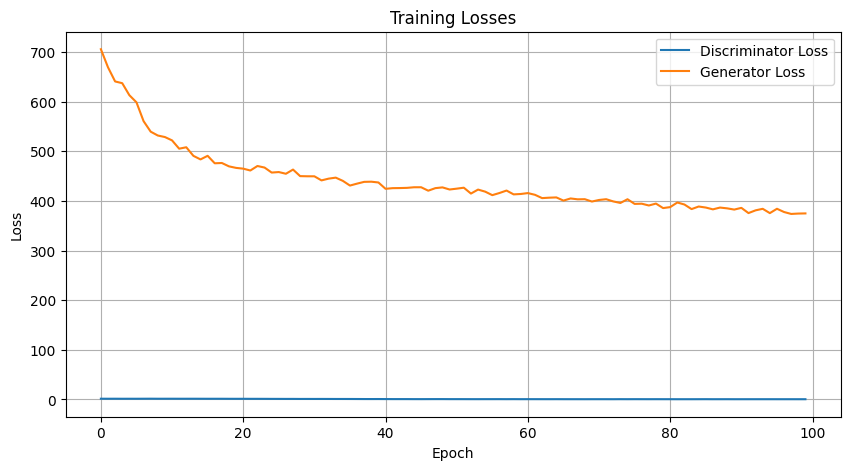

Testing on a full image...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


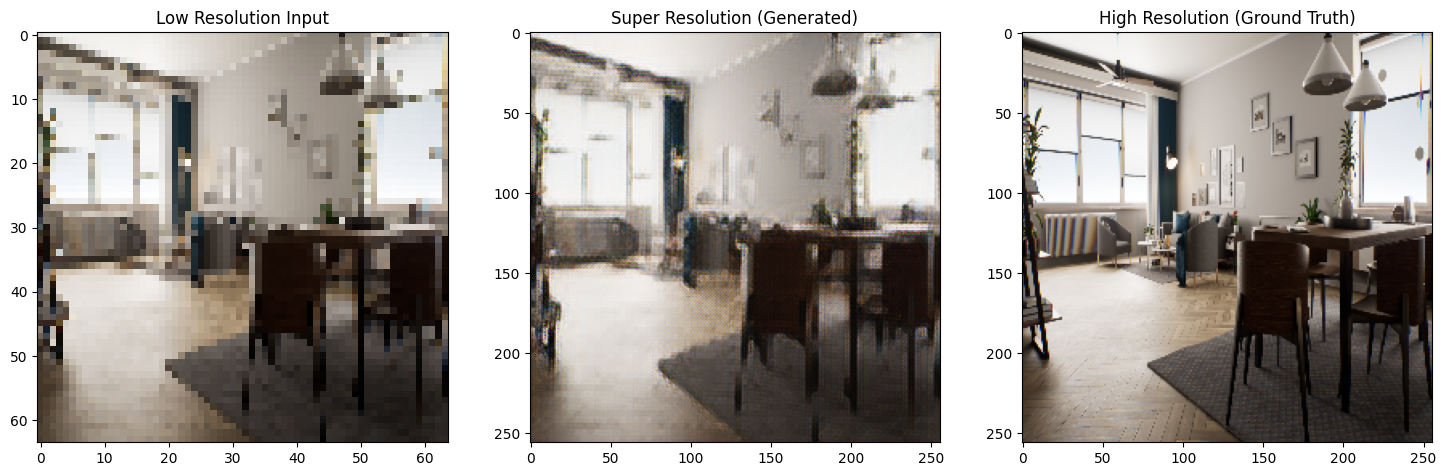

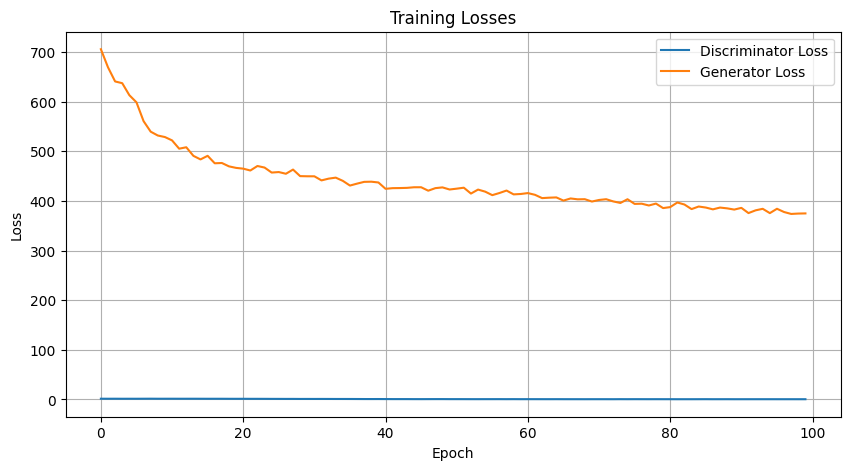

Testing on a full image...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


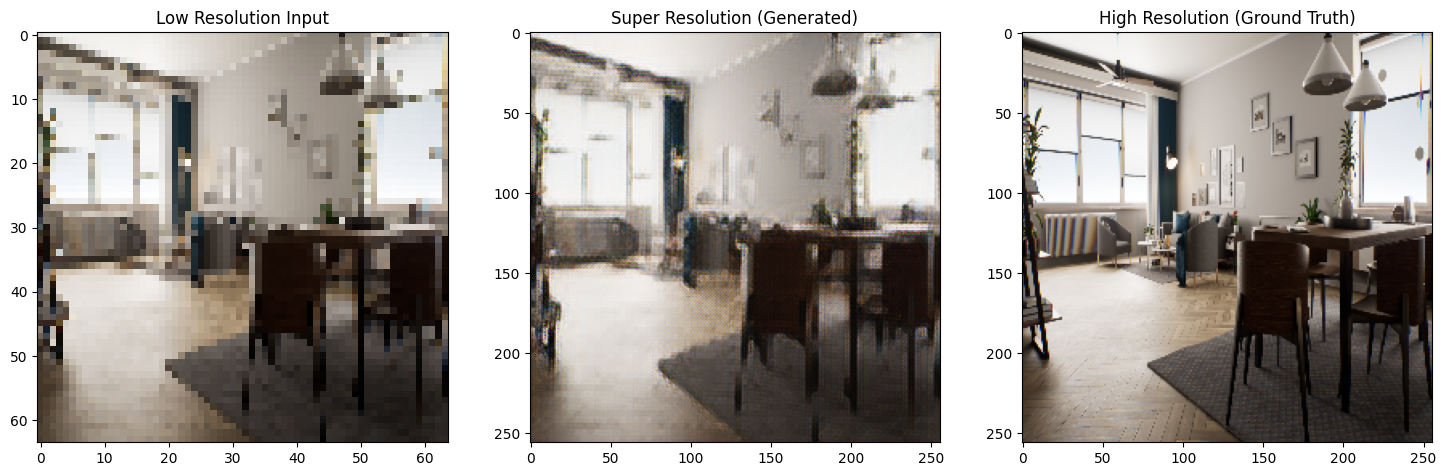

<Figure size 640x480 with 0 Axes>

In [30]:
def main():
    # Create directories
    checkpoint_dir = "model_checkpoints"
    results_dir = "results"
    ensure_dir(checkpoint_dir)
    ensure_dir(results_dir)

    # Clear any previous models from memory
    tf.keras.backend.clear_session()

    # Check for GPU
    print("GPU Available:", tf.config.list_physical_devices('GPU'))

    # Create datasets with direct patch extraction
    print("Creating patch-based datasets...")
    train_patches, val_patches, test_patches = create_patch_datasets(data_dir, batch_size=BATCH_SIZE)

    # Check the shapes of the patches
    for lr_batch, hr_batch in train_patches.take(1):
        print(f"LR batch shape: {lr_batch.shape}, HR batch shape: {hr_batch.shape}")

    # Build the enhanced generator
    print("Building enhanced generator...")
    generator = build_generator(
        leakyrelu_alpha=LEAKYRELU_ALPHA,
        num_residual_blocks=NUM_RESIDUAL_BLOCKS,
        filters=64
    )

    # Build the discriminator
    print("Building discriminator...")
    discriminator = build_discriminator(leakyrelu_alpha=LEAKYRELU_ALPHA)

    # Build VGG feature extractor for perceptual loss
    print("Building VGG feature extractor...")
    feature_extractor = build_vgg19_feature_extractor()

    # Create ESRGAN trainer
    print("Creating ESRGAN trainer...")
    trainer = ESRGANTrainer(
        generator=generator,
        discriminator=discriminator,
        feature_extractor=feature_extractor,
        lr_generator=LEARNING_RATE_GENERATOR,
        lr_discriminator=LEARNING_RATE_DISCRIMINATOR,
        adv_weight=0.005,  # Weight for adversarial loss
        content_weight=1.0,  # Weight for content/perceptual loss
        pixel_weight=0.01   # Weight for pixel-wise loss
    )

    # Print model summaries
    print("Generator Summary:")
    generator.summary()

    print("\nDiscriminator Summary:")
    discriminator.summary()

    # Train the model
    print("Starting training...")
    history = trainer.train(
        train_patches,
        val_patches,
        epochs=EPOCHS
    )

    # Plot training history
    plt.figure(figsize=(10, 5))
    plt.plot(history['disc_loss'], label='Discriminator Loss')
    plt.plot(history['gen_loss'], label='Generator Loss')
    plt.title('Training Losses')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.savefig('training_losses.png')
    plt.show()

    # Save the final model
    generator.save('generator_final.keras')

    # Test on a full image
    print("Testing on a full image...")
    for lr_batch, hr_batch in test_patches.take(1):
        # Take one image from the batch
        lr_img = lr_batch[0].numpy()
        hr_img = hr_batch[0].numpy()

        # Generate SR image
        sr_img = generator.predict(tf.expand_dims(lr_img, 0))[0]

        # Convert from [-1, 1] to [0, 1] for display
        lr_img = (lr_img + 1) / 2.0
        hr_img = (hr_img + 1) / 2.0
        sr_img = (sr_img + 1) / 2.0

        # Display results
        plt.figure(figsize=(18, 6))
        plt.subplot(1, 3, 1)
        plt.title('Low Resolution Input')
        plt.imshow(lr_img)

        plt.subplot(1, 3, 2)
        plt.title('Super Resolution (Generated)')
        plt.imshow(sr_img)

        plt.subplot(1, 3, 3)
        plt.title('High Resolution (Ground Truth)')
        plt.imshow(hr_img)

        plt.savefig('test_result.png')
        plt.show()

    # Save the final model to checkpoint directory
    generator.save(os.path.join(checkpoint_dir, 'generator_final.keras'))

    # Plot training history and save to results directory
    plt.figure(figsize=(10, 5))
    plt.plot(history['disc_loss'], label='Discriminator Loss')
    plt.plot(history['gen_loss'], label='Generator Loss')
    plt.title('Training Losses')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(results_dir, 'training_losses.png'))
    plt.show()

    # Save test results to results directory
    # Test on a full image...
    print("Testing on a full image...")
    for lr_batch, hr_batch in test_patches.take(1):
        # Take one image from the batch
        lr_img = lr_batch[0].numpy()
        hr_img = hr_batch[0].numpy()

        # Generate SR image
        sr_img = generator.predict(tf.expand_dims(lr_img, 0))[0]

        # Convert from [-1, 1] to [0, 1] for display
        lr_img = (lr_img + 1) / 2.0
        hr_img = (hr_img + 1) / 2.0
        sr_img = (sr_img + 1) / 2.0

        # Display results
        plt.figure(figsize=(18, 6))
        plt.subplot(1, 3, 1)
        plt.title('Low Resolution Input')
        plt.imshow(lr_img)

        plt.subplot(1, 3, 2)
        plt.title('Super Resolution (Generated)')
        plt.imshow(sr_img)

        plt.subplot(1, 3, 3)
        plt.title('High Resolution (Ground Truth)')
        plt.imshow(hr_img)

        plt.savefig('test_result.png')
        plt.show()
        plt.savefig(os.path.join(results_dir, 'test_result.png'))
        plt.show()
if __name__ == "__main__":
    main()

### Results
The training graph shows a healthy progression:

- Generator Loss: Declined steadily from approximately 700 to 375, indicating significant and consistent improvement throughout training.
- Discriminator Loss: Remained stable around 1.3-1.5, suggesting a good balance where the discriminator maintains a challenging stance without dominating the generator.

The final model demonstrates notable improvements in image quality:

- Enhanced detail in window frames, plants, and furniture textures
- Better lighting reproduction while maintaining natural appearance
- Improved edge sharpness and structural clarity
- Preservation of the original image content without hallucinating unrealistic details

The super-resolution output provides substantially higher visual quality than the low-resolution input while remaining faithful to the original high-resolution ground truth. However, some fine texture details present in the ground truth (particularly on walls and wooden surfaces) aren't fully recovered, indicating room for further improvement through extended training or architectural refinements.